# **Import Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Import Library**

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import zipfile

# **Ekstraksi Dataset**

In [ ]:
zip_path = "/content/drive/MyDrive/Computer Vision/dataset_strawberry_tgs_comvis.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil di-extract!")

Dataset berhasil di-extract!


# **Cek Isi Dataset di folder All**

In [ ]:
os.listdir("/content/dataset")

['all']

# **Cek Isi Dataset di folder labels**

In [ ]:
os.listdir("/content/dataset/all/labels")

['SAM_3056_JPG.rf.0bede23f42cae6eb79cde6be39e558f6.txt',
 'IMG_20250831_101008_jpg.rf.99c494c65e8c1d394a498147c7672bf1.txt',
 '20250831_102031_jpg.rf.e2b49a48cd4ca59693445f4ceebbc1dc.txt',
 'SAM_2959_JPG.rf.72198df8d737a087bd53db0e21717469.txt',
 'IMG_20250831_103620_jpg.rf.a3a84a5dec05c452971d6b0f37bf4698.txt',
 '20250831_101724_jpg.rf.52d145c73b3e149bbbf3433de049b5a1.txt',
 '20250831_114007_jpg.rf.6ef6706aca7b65ddf595cb7544118731.txt',
 'IMG_20250831_101026_jpg.rf.1d5cbf39cc7275fa814df4f4fa41b23f.txt',
 'IMG_20250830_103413_jpg.rf.07f8cd83914376b625c407f3f2851589.txt',
 'IMG_20250830_103542_jpg.rf.b3c5242bc5332f739bc5198ccc7edf35.txt',
 'IMG_20250831_101438_jpg.rf.acd36f24aa42159de08b8eaca2e6a2c5.txt',
 'SAM_3022_JPG.rf.44f35e3db29c1adb6d1e3707fda97e41.txt',
 '20250831_103637_jpg.rf.ab98865c65080ce627a794b2a71447ac.txt',
 'IMG_20250831_103136_jpg.rf.22c69361676560cbd07a8e4cf761fcc7.txt',
 'IMG_20250831_100753_jpg.rf.c78fa81c37b48a440cc05c7ba425b445.txt',
 '20250831_114042_jpg.rf.68c6

# **Cek Isi Dataset di folder images**

In [ ]:
os.listdir("/content/dataset/all/images")

['20250831_100714_jpg.rf.406bbbd0ac982ffa814a5e121b5611ae.jpg',
 '20250831_101910_jpg.rf.ed065e62075b2ac681ab27505076f441.jpg',
 '20250831_103549_jpg.rf.74a757fb089917e518f7f6ebf308efbb.jpg',
 'IMG_20250831_101704_jpg.rf.df4eeb012f81d28a77d66050fda02cb7.jpg',
 'SAM_3052_JPG.rf.a657f7e7f4d6b45c6114d4fe3fc7f998.jpg',
 '20250831_102126_jpg.rf.e4ee894954f64d5d7c79444727eba067.jpg',
 'IMG_20250831_102043_jpg.rf.07d1b0dbd621c9f83c952f5865492559.jpg',
 'IMG_20250830_102455_jpg.rf.d4c55ca8d7ca3070282e78e9c63acd80.jpg',
 'IMG_20250831_101008_jpg.rf.99c494c65e8c1d394a498147c7672bf1.jpg',
 'IMG_20250830_103943_jpg.rf.da7d28c447e62577311511e2440924ed.jpg',
 'IMG_20250831_100858_jpg.rf.67dd01dfca51381d877a754327463c06.jpg',
 '20250831_114625_jpg.rf.d184c5d43efab9e97c048aa2e9671805.jpg',
 'SAM_2989_JPG.rf.58b92e45ed1d3efb70f5552f49df06a1.jpg',
 '20250831_103153_jpg.rf.f331a9bd691e43b0ac0effbddf5a48a8.jpg',
 '20250831_101925_jpg.rf.c4b48c28b08ab2eb59792b6bd976af02.jpg',
 'SAM_3059_JPG.rf.5c9638f7d2a4

# **Pilih Gambar**

In [ ]:
image_folder = "/content/dataset/all/images"

# ambil semua nama gambar
images = sorted(os.listdir(image_folder))

selected_images = images[10:20]

print(selected_images)

['20250831_095648_jpg.rf.24f62d130fde3272d6b7c4062923812e.jpg', '20250831_095702_jpg.rf.fe7765e77d10daccb6b4d64b936cb719.jpg', '20250831_095719_jpg.rf.5307e2dd221106b14e76864894afca80.jpg', '20250831_095820_jpg.rf.09a51b7204d639ecba47329cb538b7b0.jpg', '20250831_095834_jpg.rf.be90220d507406889d57778c9a852ac9.jpg', '20250831_095849_jpg.rf.ebb2f16f2fc89e62a03cb429a805ce36.jpg', '20250831_095915_jpg.rf.663441d87d70193838234ae80e7d0cfe.jpg', '20250831_095937_jpg.rf.ce4f764a91646a4d23fdeda046aa06c7.jpg', '20250831_095944_jpg.rf.dfaf8a2b08101bfc7aea4366b0943fc4.jpg', '20250831_100000_jpg.rf.fb5970755a88d3ba93019131865f4f4e.jpg']


# **Hitung jumlah gambar**

In [ ]:
len(selected_images)

10

# **Hitung jumlah gambar**

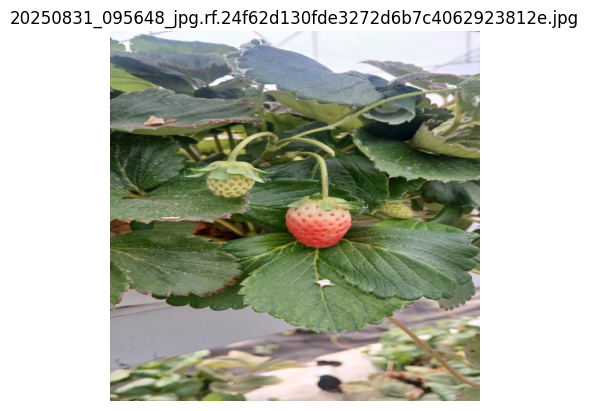

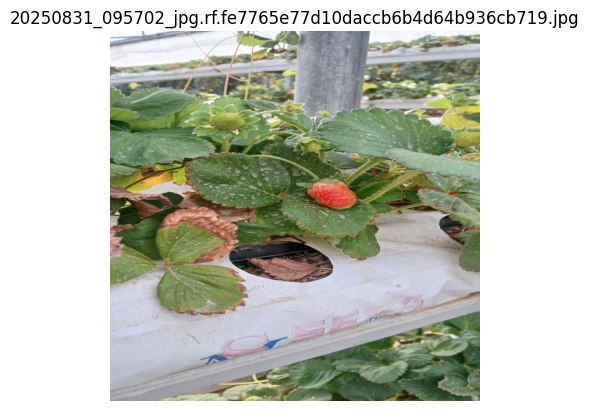

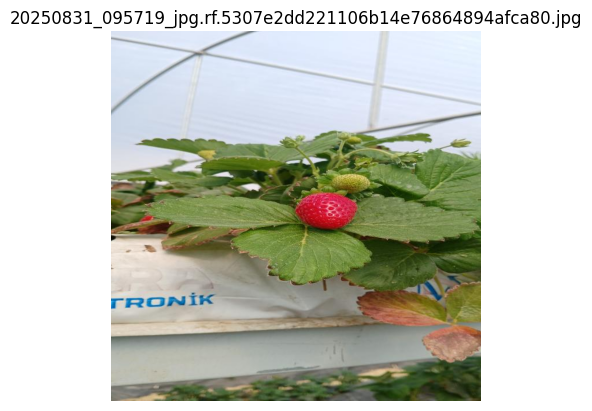

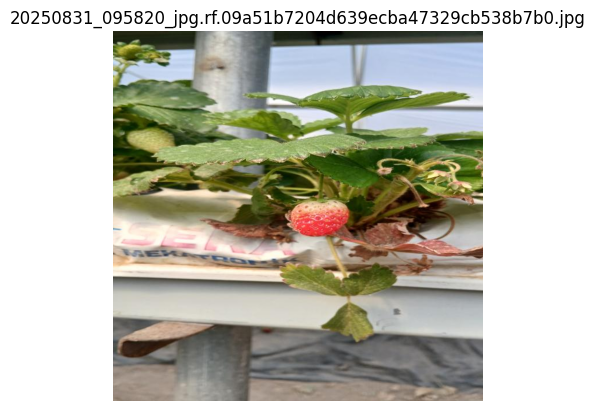

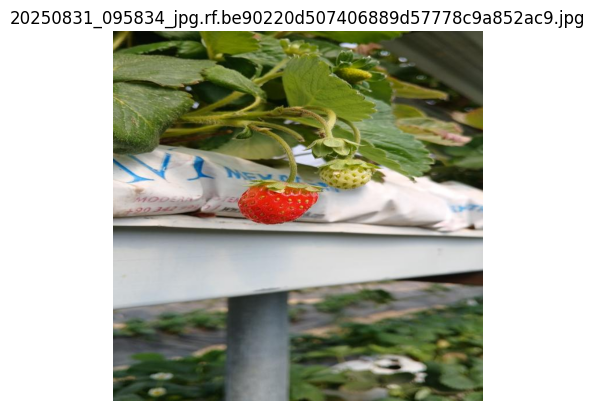

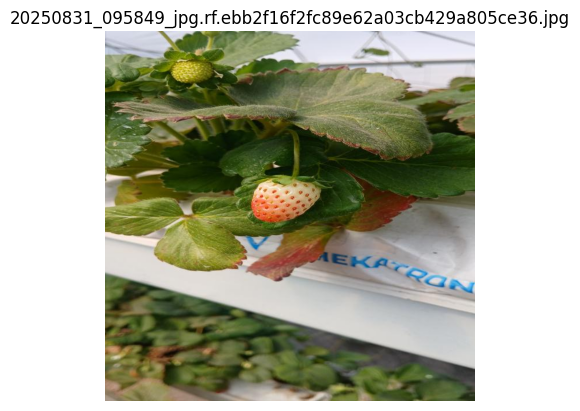

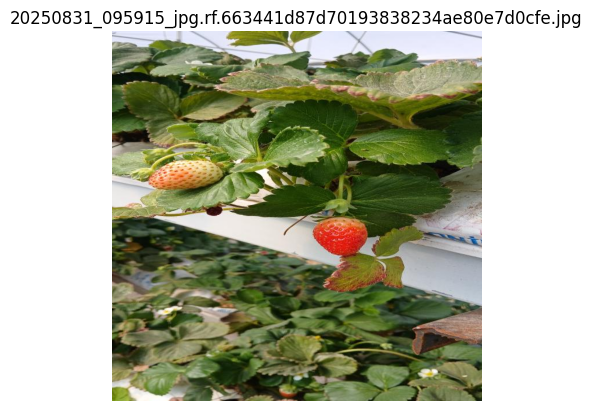

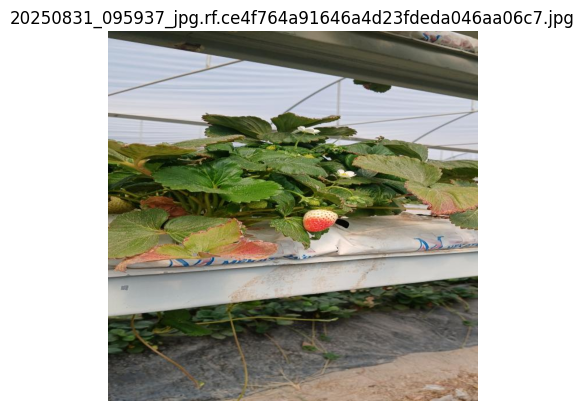

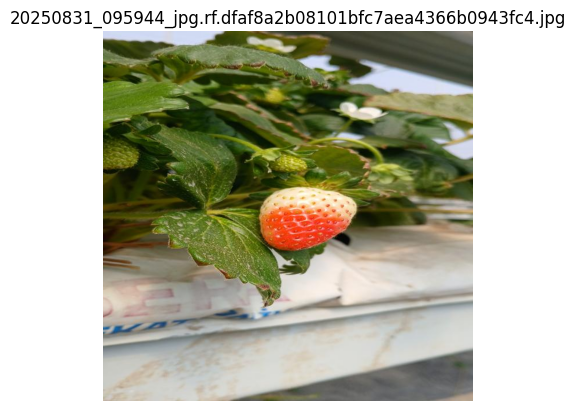

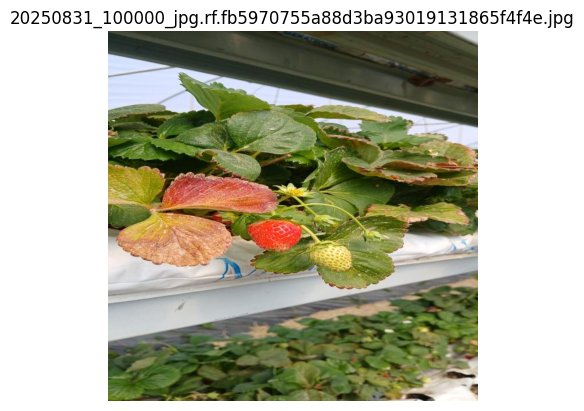

In [ ]:
for img_name in selected_images:
    img_path = os.path.join(image_folder, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')
    plt.show()

# **Ekstraksi Fitur Warna**

In [ ]:
feature_data = []

for img_name in selected_images:

    # path gambar
    img_path = os.path.join(image_folder, img_name)

    img = cv2.imread(img_path)

    # ubah BGR ke RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # hitung rata-rata warna
    mean_r = np.mean(img[:,:,0])
    mean_g = np.mean(img[:,:,1])
    mean_b = np.mean(img[:,:,2])

    # simpan hasil
    feature_data.append([img_name, mean_r, mean_g, mean_b])

print("Ekstraksi selesai!")

Ekstraksi selesai!


# **DataFrame**

In [ ]:
import pandas as pd

# ubah ke dataframe
df = pd.DataFrame(
    feature_data,
    columns=["Nama_Gambar", "Mean_R", "Mean_G", "Mean_B"]
)

df

,Nama_Gambar,Mean_R,Mean_G,Mean_B
0,20250831_095648_jpg.rf.24f62d130fde3272d6b7c40...,128.269739,134.562654,111.317739
1,20250831_095702_jpg.rf.fe7765e77d10daccb6b4d64...,143.127607,149.175742,127.413699
2,20250831_095719_jpg.rf.5307e2dd221106b14e76864...,155.711077,160.500835,140.308545
3,20250831_095820_jpg.rf.09a51b7204d639ecba47329...,142.190020,140.816978,118.325369
4,20250831_095834_jpg.rf.be90220d507406889d57778...,121.342476,124.735049,97.331489
5,20250831_095849_jpg.rf.ebb2f16f2fc89e62a03cb42...,120.983086,123.491121,91.330542
6,20250831_095915_jpg.rf.663441d87d70193838234ae...,112.554478,117.888833,78.753811
7,20250831_095937_jpg.rf.ce4f764a91646a4d23fdeda...,125.018433,124.887646,106.393660
8,20250831_095944_jpg.rf.dfaf8a2b08101bfc7aea436...,131.250369,131.283945,99.155881
9,20250831_100000_jpg.rf.fb5970755a88d3ba9301913...,122.430469,121.795242,85.220967


# **Simpan File xlsx**

In [ ]:
save_path_excel = "/content/drive/MyDrive/Computer Vision/hasil_ekstraksi_fitur.xlsx"

df.to_excel(save_path_excel, index=False)

print("File Excel berhasil dibuat!")

File Excel berhasil dibuat!


# **Grafik RGB**

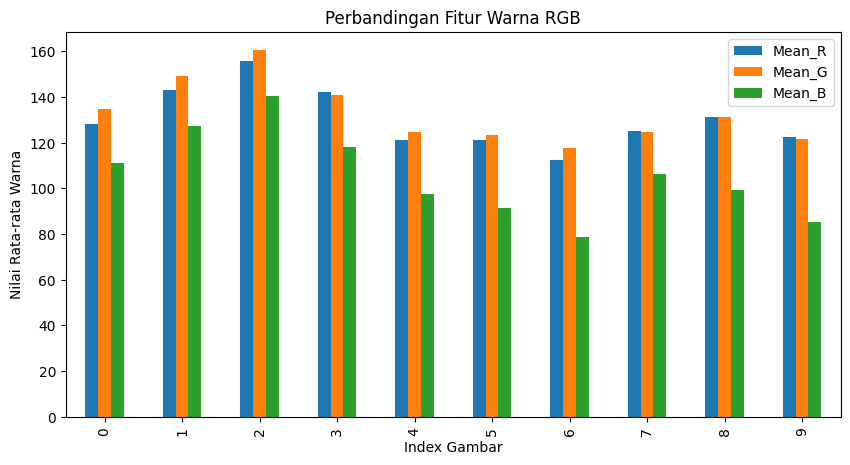

In [ ]:
import matplotlib.pyplot as plt

df[["Mean_R","Mean_G","Mean_B"]].plot(kind="bar", figsize=(10,5))

plt.title("Perbandingan Fitur Warna RGB")
plt.xlabel("Index Gambar")
plt.ylabel("Nilai Rata-rata Warna")
plt.show()

# **Analisis Statistik Fitur Warna RGB**

In [ ]:
df.describe()

,Mean_R,Mean_G,Mean_B
count,10.000000,10.000000,10.000000
mean,130.287775,132.913804,105.555170
std,13.031742,13.592484,19.221785
min,112.554478,117.888833,78.753811
25%,121.614474,123.802103,92.830779
50%,126.644086,128.085796,102.774771
75%,139.455107,139.253397,116.573461
max,155.711077,160.500835,140.308545


# **Visualisasi Rata-rata Warna Dataset**

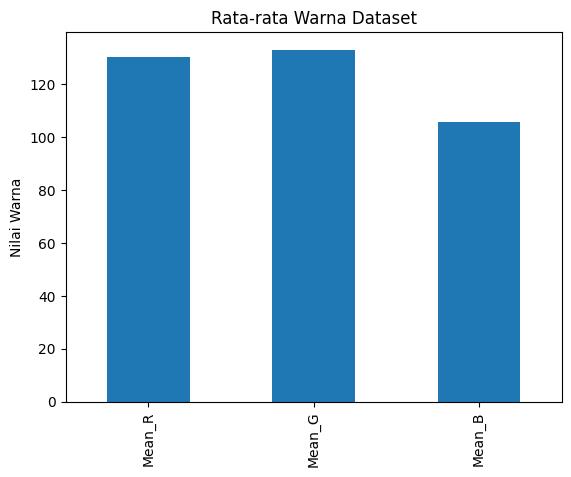

In [ ]:
df[["Mean_R","Mean_G","Mean_B"]].mean().plot(kind="bar")

plt.title("Rata-rata Warna Dataset")
plt.ylabel("Nilai Warna")
plt.show()